![Astrofisica Computacional](../logo.PNG)

# ---
## 02. Generative Adversay Neural Networks (GANNs)


Eduard Larrañaga (ealarranaga@unal.edu.co)

---

### Abstract

In this notebook we will present a second example of a Generative Adversary Neural Network (GANN).

---

---

## Generative Adversary Neural Networks (GANNs)

As a second example of a Generative Adversary Neural Network (GANN), we will implement an algorithm that generates handwritten numbers . 


The first step is to load the needed libraries and to define a seed for random numbers in [pytorch](https://pyTorch.org).


In [1]:
import torch
from torch import nn

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
%matplotlib inline

import torchvision
import torchvision.transforms as transforms

torch.manual_seed(413)

This example will use images for the training and therefore the model will be more complex, including a larger number of parameters. Then, the training process will be slower. Using a CPU it will take about two minutes per epoch, meaning that training for fifty epochs implies a total training time of around one hundred minutes (i.e. one hour and forty minutes!).

In order to reduce the training time we can use a GPU. Therefore, we will create a device object that points either to the CPU or to the GPU,

In [2]:
device = ""
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

## The Training Data

The training of the algorithm will be done using the MNIST dataset, which consists of 60000 samples of 28 × 28 pixel grayscale images of handwritten digits from 0 to 9. 

To use these images with PyTorch, it is needed to perform some conversions. Then, we define a transform function to be used when loading the data. This function will use two methods,

1. The method `transforms.ToTensor()` converts the data to a PyTorch tenso`.

2. The method `transforms.Normalize()` modifies the range of the tensor coefficients.

The original coefficients given by transforms.ToTensor() range from 0 to 1, and since the image backgrounds are black, most of the coefficients are equal to 0 when they’re represented using this range.

transforms.Normalize() changes the range of the coefficients to -1 to 1 by subtracting 0.5 from the original coefficients and dividing the result by 0.5. With this transformation, the number of elements equal to 0 in the input samples is dramatically reduced, which helps in training the models.

The arguments of transforms.Normalize() are two tuples, (M₁, ..., Mₙ) and (S₁, ..., Sₙ), with n representing the number of channels of the images. Grayscale images such as those in MNIST dataset have only one channel, so the tuples have only one value. Then, for each channel i of the image, transforms.Normalize() subtracts Mᵢ from the coefficients and divides the result by Sᵢ.

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)

In [4]:
train_set = torchvision.datasets.MNIST(
    root=".", train=True, download=True, transform=transform
)

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



In [5]:
train_set

Dataset MNIST
    Number of datapoints: 60000
    Root location: .
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

Now, we will generate the training fata by defining pairs fo numbers with the form $(x,y)$ where x will be a random number in the interval $[0,2\pi)$ and $y = \sin x$. The data will be given as a tensor with $1024 \times 2$ entries,


In [6]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

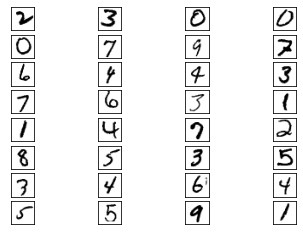

In [7]:
real_samples, mnist_labels = next(iter(train_loader))
for i in range(32):
    ax = plt.subplot(8, 4, i + 1)
    plt.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
    plt.xticks([])
    plt.yticks([])
    #print(mnist_labels[i])

In [8]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(nn.Linear(784, 1024),
                               nn.ReLU(),
                               nn.Dropout(0.3),
                               nn.Linear(1024, 512),
                               nn.ReLU(),
                               nn.Dropout(0.3),
                               nn.Linear(512, 256),
                               nn.ReLU(),
                               nn.Dropout(0.3),
                               nn.Linear(256, 1),
                               nn.Sigmoid(),
                               )
  def forward(self, x):
    x = x.view(x.size(0), 784)
    output = self.model(x)
    return output

In [9]:
discriminator = Discriminator().to(device=device)

In [10]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(nn.Linear(100, 256),
                               nn.ReLU(),
                               nn.Linear(256, 512),
                               nn.ReLU(),
                               nn.Linear(512, 1024),
                               nn.ReLU(),
                               nn.Linear(1024, 784),
                               nn.Tanh(),
                               )
  def forward(self, x):
    output = self.model(x)
    output = output.view(x.size(0), 1, 28, 28)
    return output

generator = Generator().to(device=device)

Note that the train set includes a column with labels. However, the GANN is an unsupervised algorithm and therefore this column won't be used.

The training data is plotted in the following figure,

In [11]:
lr = 0.0001
num_epochs = 50
loss_function = nn.BCELoss()

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

In [ ]:
for epoch in range(num_epochs):
  for n, (real_samples, mnist_labels) in enumerate(train_loader):
    # Data for training the discriminator
    real_samples = real_samples.to(device=device)
    real_samples_labels = torch.ones((batch_size, 1)).to(device=device)
    latent_space_samples = torch.randn((batch_size, 100)).to(device=device)
    generated_samples = generator(latent_space_samples)
    generated_samples_labels = torch.zeros((batch_size, 1)).to(device=device)
    all_samples = torch.cat((real_samples, generated_samples))
    all_samples_labels = torch.cat(
                                (real_samples_labels, generated_samples_labels)
                                )
    
    # Training the discriminator
    discriminator.zero_grad()
    output_discriminator = discriminator(all_samples)
    loss_discriminator = loss_function(
                                      output_discriminator, all_samples_labels
                                       )
    loss_discriminator.backward()
    optimizer_discriminator.step()
    
    # Data for training the generator
    latent_space_samples = torch.randn((batch_size, 100)).to(device=device)
    
    # Training the generator
    generator.zero_grad()
    generated_samples = generator(latent_space_samples)
    output_discriminator_generated = discriminator(generated_samples)
    loss_generator = loss_function(
                            output_discriminator_generated, real_samples_labels
                                  )
    loss_generator.backward()
    optimizer_generator.step()
    
    # Show loss
    if n == batch_size - 1:
      print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
      print(f"Epoch: {epoch} Loss G.: {loss_generator}")

Epoch: 0 Loss D.: 0.5460954308509827
Epoch: 0 Loss G.: 0.5196390151977539
Epoch: 1 Loss D.: 0.03203979507088661
Epoch: 1 Loss G.: 5.887201309204102
Epoch: 2 Loss D.: 1.953581340785604e-05
Epoch: 2 Loss G.: 19.90135955810547
Epoch: 3 Loss D.: 0.05866515263915062
Epoch: 3 Loss G.: 4.410460472106934
Epoch: 4 Loss D.: 0.13341952860355377
Epoch: 4 Loss G.: 4.508058071136475
Epoch: 5 Loss D.: 0.0023096834775060415
Epoch: 5 Loss G.: 7.042123794555664
Epoch: 6 Loss D.: 0.017548123374581337
Epoch: 6 Loss G.: 5.721497535705566
Epoch: 7 Loss D.: 3.3681113563943654e-05
Epoch: 7 Loss G.: 13.84892463684082
Epoch: 8 Loss D.: 0.00010313398524885997
Epoch: 8 Loss G.: 9.76366901397705
Epoch: 9 Loss D.: 1.821924524847418e-05
Epoch: 9 Loss G.: 10.769989013671875
Epoch: 10 Loss D.: 2.3718999727861956e-05
Epoch: 10 Loss G.: 10.825289726257324
Epoch: 11 Loss D.: 3.462072527327109e-06
Epoch: 11 Loss G.: 21.051870346069336
Epoch: 12 Loss D.: 0.0
Epoch: 12 Loss G.: 97.55152893066406
Epoch: 13 Loss D.: 0.0
Epoch

To use this data in `pyTorch`, we need to defin a data loader using the function [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html) with a batch size of 32 elements and shuffling the elements in the dataset.

In [ ]:
latent_space_samples = torch.randn(batch_size, 100).to(device=device)
generated_samples = generator(latent_space_samples)

## The Neural Networks

We need to implement the Neural Networks (NN).

### The Discriminator

First, the Discriminator NN will be an object of the [nn.Module()](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) class with a [sequential model](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html). The layers will be created with the following structure,

- Linear layer with 2 inputs, 256 outputs and a ReLU activation.
- Dropout (30%) layer to prevent overfitting
- Linear layer with 256 inputs, 128 outputs and a ReLU activation.
- Dropout (30%) layer to prevent overfitting
- Linear layer with 128 inputs, 64 outputs and a ReLU activation.
- Dropout (30%) layer to prevent overfitting
- Linear layer with 64 inputs, 1 outputs and a sigmoid activation in order to represent a probability.

We also define the method `.forward()` that calculates the output of the model using the input 2-dimensional tensor `x`.


In [ ]:
generated_samples = generated_samples.cpu().detach()
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(generated_samples[i].reshape(28, 28), cmap="gray_r")
    plt.xticks([])
    plt.yticks([])

### The Generator

The Generator NN will also be an object of the [nn.Module()](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) class with a [sequential model](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html). This network receives an input consisting of two random points and will produce a 2-dimensional output resembling the $\sin$ function. The layers will be created with the following structure,

- Linear layer with 2 inputs, 16 outputs and a ReLU activation.
- Linear layer with 16 inputs, 32 outputs and a ReLU activation.
- Linear layer with 32 inputs and 2 outputs. No activation is introduced for this layer.

We also define the method `.forward()` that calculates the genrated output from the input 2-dimensional tensor `x`.


In [ ]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(nn.Linear(2, 16),
                               nn.ReLU(),
                               nn.Linear(16, 32),
                               nn.ReLU(),
                               nn.Linear(32, 2),)
  def forward(self, x):
    output = self.model(x)
    return output

generator = Generator()

### Optimizer

We will use the [torch.optim.Adam()](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) optimizer for both networks with a learning rate of $0.001$. Note that the ADAM optimizer access the parameters of the neural networks through the method `.parameters()`.

In [ ]:
lr = 0.001

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

## Training the Model

We will train the model through 300 epochs and the loss function will be the Binary Cross Entropy, [nn.BCELoss()](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html).

Next, we implement a double `for` loop to train the networks. The outer loop counts the epochs while the inner loop counts the batches in each epoch. Note that for GANs, the parameters of both, the discriminator and the generator, are updated at each iteration.

We first proceed with the training of the discriminator in two steps:

* Using the Generator, we obtain the `generated_samples` and these are concatenated with the `real_samples` using the [torch.cat( )](https://pytorch.org/docs/stable/generated/torch.cat.html) function. Similarly, we concatenate the `real_samples_labels` (ones) and the `generated_samples_labels` (zeros).

* The training of the discriminator begins with a clear of the gradients (this is necessary in `pyTorch` in order to avoid an accumulation of values). Then, we calculate the output and evaluate the loss function for all the samples comparing with all the labels.
The method `.backward()` calaculates the gradients and the `.step()` updates the parameters of the discriminator.

The training of the generator is done in two steps:

*  First, we create random data points for the latent space and generate the samples.

* After clearing the gradients, we apply the generated samples to the discriminator and the obtained outputs are evaluated with the loss function by comparing with the real labels. Using the methods `.backward()` and `.step()` we calaculate the gradients and update the parameters of the generator.

Finally, we print some training information.

In [ ]:

def training(num_epochs, loss_function):
  history = []
  for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
      
      # Data for training the discriminator
      real_samples_labels = torch.ones((batch_size, 1))

      latent_space_samples = torch.randn((batch_size, 2))
      generated_samples = generator(latent_space_samples)
      generated_samples_labels = torch.zeros((batch_size, 1))

      all_samples = torch.cat((real_samples, generated_samples))
      all_samples_labels = torch.cat(
                                  (real_samples_labels, generated_samples_labels)
                                    )
      
      # Training the discriminator
      discriminator.zero_grad()
      output_discriminator = discriminator(all_samples)
      loss_discriminator = loss_function(output_discriminator, all_samples_labels)
      loss_discriminator.backward()
      optimizer_discriminator.step()
      
      # Data for training the generator
      latent_space_samples = torch.randn((batch_size, 2))
      generated_samples = generator(latent_space_samples)
      
      # Training the generator
      generator.zero_grad()
      output_discriminator_generated = discriminator(generated_samples)
      loss_generator = loss_function(
                            output_discriminator_generated, real_samples_labels
                                    )
      loss_generator.backward()
      optimizer_generator.step()
      
      # Show loss
      if epoch % 10 == 0 and n == batch_size - 1:
        print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
        print(f"Epoch: {epoch} Loss G.: {loss_generator}")
        im = image_plot()
        history.append(im)
  
  return history
        


def image_plot():
  plot_samples = torch.randn(100, 2)
  plot_generated_samples = generator(plot_samples)
  return plot_generated_samples.detach()
  


num_epochs = 500
loss_function = nn.BCELoss()

history = training(num_epochs, loss_function)

Epoch: 0 Loss D.: 0.36355510354042053
Epoch: 0 Loss G.: 1.4468053579330444
Epoch: 10 Loss D.: 0.39516112208366394
Epoch: 10 Loss G.: 1.097031831741333
Epoch: 20 Loss D.: 0.5623492002487183
Epoch: 20 Loss G.: 1.0304981470108032
Epoch: 30 Loss D.: 0.6547618508338928
Epoch: 30 Loss G.: 0.9232233762741089
Epoch: 40 Loss D.: 0.6160207390785217
Epoch: 40 Loss G.: 1.002445936203003
Epoch: 50 Loss D.: 0.679754912853241
Epoch: 50 Loss G.: 0.7925245761871338
Epoch: 60 Loss D.: 0.6505866050720215
Epoch: 60 Loss G.: 0.7591979503631592
Epoch: 70 Loss D.: 0.699058473110199
Epoch: 70 Loss G.: 0.7913150787353516
Epoch: 80 Loss D.: 0.6947400569915771
Epoch: 80 Loss G.: 0.7124261856079102
Epoch: 90 Loss D.: 0.6973849534988403
Epoch: 90 Loss G.: 0.7147971391677856
Epoch: 100 Loss D.: 0.7062497138977051
Epoch: 100 Loss G.: 0.676814615726471
Epoch: 110 Loss D.: 0.6885471940040588
Epoch: 110 Loss G.: 0.8748753070831299
Epoch: 120 Loss D.: 0.7145898938179016
Epoch: 120 Loss G.: 0.7292919158935547
Epoch: 130 

## Probing the Neural Network

Once the neural network is trained, we will probe its results by considering a latent space with 100 random samples.

In [ ]:
latent_space_samples = torch.randn(100, 2)
generated_samples = generator(latent_space_samples)

The generated samples are plotted to see the fitness of the network. Note the use of the method `.detach()` to extract the data from the resulting tensor.

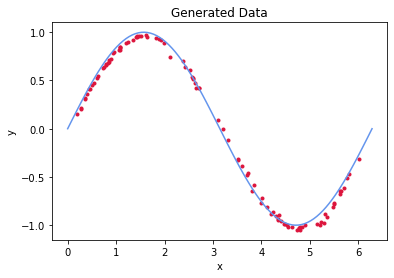

In [ ]:
generated_samples = generated_samples.detach()

xx = np.linspace(0,2*np.pi,100)

plt.figure()
plt.plot(generated_samples[:, 0], generated_samples[:, 1], '.', color='crimson')
plt.plot(xx, np.sin(xx), color='cornflowerblue')
plt.xlabel(r'x')
plt.ylabel(r'y')
plt.title('Generated Data')
plt.show()

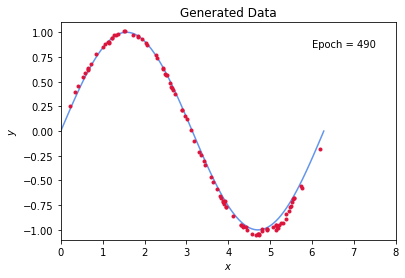

In [ ]:
# Set up the figure, the axis, and the plot element we want to animate
fig, ax = plt.subplots()
xx = np.linspace(0,2*np.pi,100)
ax.plot(xx, np.sin(xx), color='cornflowerblue')
ax.set_xlim((0, 8))
ax.set_ylim((-1.1, 1.1))
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
plt.title('Generated Data')

line, = ax.plot([], [], '.', color='crimson')
title = ax.text(6,0.85, "")

# Define the initialization function, which plots the background of each frame
def init():
    line.set_data([], [])
    #title.set_data([])
    return (line,)

def animate(i):
    #step = int(len(tgrid)/200)
    # We take only some of the frames (given by 50*i)
    line.set_data(history[i][:,0], history[i][:,1])
    title.set_text(f'Epoch = {10*i}')
    return (line,)

anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=len(history), interval=150,  # duration of 20 ms each
                               blit=True)

HTML(anim.to_jshtml())